# Hernquist distribution
The aim of this notebook is to generate an unperturbed Hernquist distribution. We will then add two extra points which will simulate two black holes, to study the dynamical friction and their interaction.

The Henrquist profile is described by the follwing density distribution:

$$ \rho(r) = \frac{M}{2\pi}\frac{a}{r}\frac{1}{(r+a)^3} $$   
where $a$ is a scale radius. Note that for radii larger than $a$, the density goes as $r^{-4}$, at smaller radii it will instead go as r.

From the density distribution one can compute the mass distribution and the potential shape, assuming a spherical distribution. 

$$ M(R) = \int_0^R 4\pi r^2 \rho(r) dr  = \frac{M_{tot}R^2}{(R+a)^2}$$

$$ \phi_H (R) = -4\pi G\Bigl[\frac{1}{R} \int_0^R \rho(r) r^2 dr + \int_R^\infty \rho(r) r dr\Bigr] = - \frac{GM}{(R+a)}$$

In [1]:
#pip install scienceplots

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import scienceplots
plt.style.use(['science', 'no-latex'])

## Initialization

In [3]:
n = 10000 #number of particles
a = 2.0 #scale radius
M = 1.0 #each particle has a mass = M/n in internal units
n_dim = 3

In [4]:
def radius(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)
    
def v_circ(radius):
    return np.sqrt(M * radius) / (radius + a)

In [5]:
M_BH = M / 10

x_1, y_1, z_1 = 10.0, 0.0, 0.0
x_2, y_2, z_2 = -10.0, 0.0, 0.0
r_1 = radius(x_1, y_1, z_1)
r_2 = radius(x_2, y_2, z_2)

v_x1, v_y1, v_z1 = 0.0, v_circ(r_1), 0.0
v_x2, v_y2, v_z2 = 0.0, - v_circ(r_2), 0.0

## Position sampling
In order to create the profile, we need to sample the position and velociy of each of our n particles. To do this, we first find the radial distribution:

$$ P(R) = \frac{M(R)}{M_{tot}} = \frac{R^2}{(R + a)^2} $$

where $0 < P(R) < 1$. In this way we can sample from a uniform distribution and then convert that value into a radius:

$$ R = \frac{a\sqrt{P(R)}}{1-\sqrt{P(R)}}$$

Assuming spherical symmetry, the angular positions can instead be generated from:


$$ \Theta = \arccos{(1-2P(\Theta))}$$

$$ \Phi = {2\pi}P(\Phi)$$

where P once again is drawn from a uniform distribution.

In [6]:
def radius_from_P (P):
    return (a * np.sqrt(P)) / (1 - np.sqrt(P))

In [7]:
#samples ---------------------------------
P_R = np.random.uniform(0, 1, n)
radius = radius_from_P (P_R)
radius_s = np.sort(radius)
r_inverse = radius_s[::-1] #we will need the arr that goes from rmax to rmin later

P_theta = np.random.uniform(0, 1, n)
theta = np.arccos(1 - 2*P_theta)

P_phi = np.random.uniform(0, 1, n)
phi = 2 * np.pi * P_phi

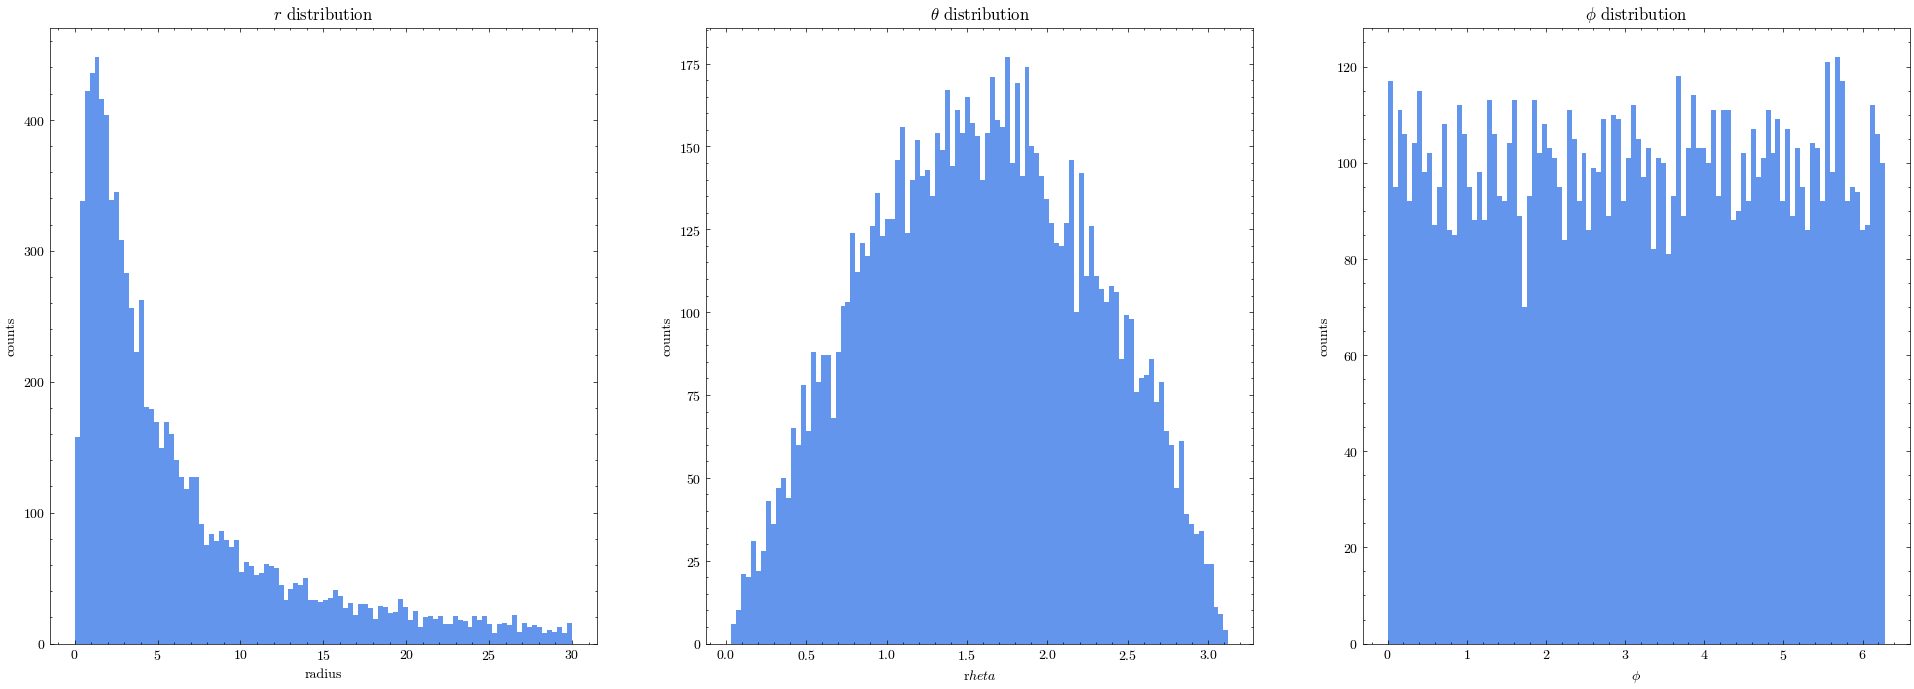

In [8]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(radius_s, range=(0,30), bins = 100, color = 'cornflowerblue')
ax[0].set(title = '$r$ distribution', ylabel = "counts", xlabel = "radius")

ax[1].hist(theta, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[1].set(title = r'$\theta$ distribution', ylabel = "counts", xlabel = 'r$\theta$')
ax[1].plot()

ax[2].hist(phi, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[2].set(title = '$\phi$ distribution', ylabel = "counts", xlabel = "$\phi$")
ax[2].plot()

plt.show()

In [9]:
#carthesian coord conversion -----------
def sph_to_carth (radius, theta, phi):
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z

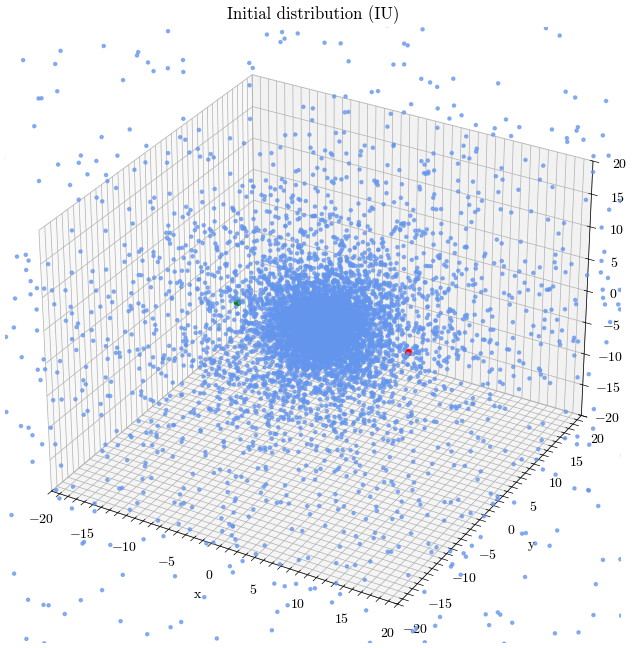

In [10]:
x, y, z = sph_to_carth(radius_s, theta, phi)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(x,y,z,s=5,alpha=0.7, color = 'cornflowerblue')
ax.scatter(x_1, y_1, z_1, color = 'r')
ax.scatter(x_2, y_2, z_2, color = 'g')
ax.set (title = 'Initial distribution (IU)', xlabel = 'x', ylabel = 'y', zlabel = 'z', xlim = (-20,20), ylim = (-20, 20), zlim = (-20, 20))

plt.show()

## Density check

In [11]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

In [12]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    
    for i in range(n_check-1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 1:
            grid_centres.append(float(grid[i+1]))
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid_centres[len(grid_centres)-2]**3)
            rho.append( (M/n) * (dn/dV) )
    
    return rho, grid_centres

In [13]:
num_rho, rho_grid = numerical_density(radius_s, 500)

analytical_rho = [compute_rho(rg) for rg in rho_grid]

/tmp/ipykernel_6948/2502167543.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  rho.append( (M/n) * (dn/dV) )


[]

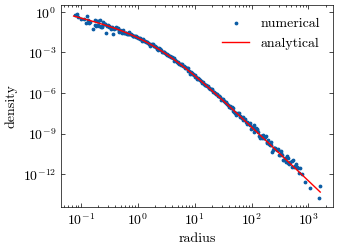

In [14]:
plt.scatter(rho_grid, num_rho, s = 3, label ='numerical')
plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
plt.xlabel('radius')
plt.ylabel('density')
plt.legend()
plt.loglog()

## Velocity sampling

In [15]:
def compute_potential(radius):
    return - M / (radius + a)
    
def distribution_function(eps):
    v_g = np.sqrt(M/a)
    factor_1 = M/(8 * np.sqrt(2) * np.pi**3 * a**3 * v_g**3)
    factor_2 = 1 / (1-eps**2)**(5/2)
    term_1 = (3 * np.arcsin(eps))
    term_2 = eps * np.sqrt(1-eps**2) * (1-2*eps**2) * (8*eps**4 - 8*eps**2 - 3)

    return factor_1 * factor_2 * (term_1 + term_2)
    
def v_escape(radius):
    return np.sqrt(- 2 * compute_potential(radius))

<function matplotlib.pyplot.show(close=None, block=None)>

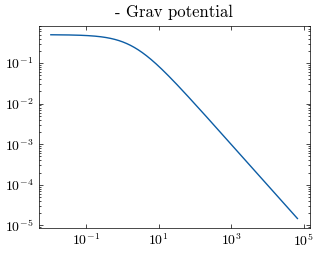

In [16]:
potential = - compute_potential(r_inverse)

plt.plot(r_inverse, potential)
plt.title('- Grav potential')
plt.loglog()
plt.show

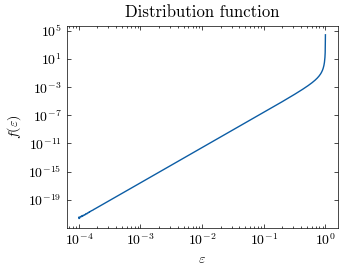

In [17]:
eps_values = np.geomspace(0.0001, 0.999, 1000)
f_values = distribution_function(eps_values)

norm = np.trapezoid(f_values, eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Distribution function')
plt.loglog()
plt.show()

In [18]:
print(f_values[f_values<0])

[]


In [19]:
print(norm)

122.89288054215112


In [20]:
def df_norm(eps):
    eps = np.sqrt(- eps / compute_potential(0) )
    return distribution_function(eps)/norm

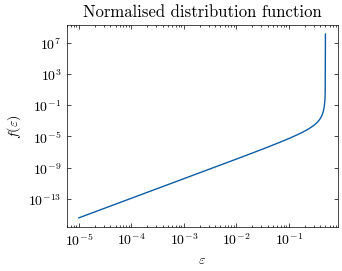

In [21]:
eps_values = np.geomspace(0.00001, - 0.99999 * compute_potential(0), 1000)
f_values = df_norm(eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Normalised distribution function')
plt.loglog()
plt.show()

In [22]:
from tqdm import tqdm

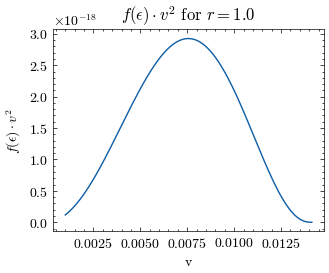

In [23]:
r=1E+4
phi_r = compute_potential(r)
v_max = v_escape(r)

v_vals = np.linspace(0.001, v_max, 500)
epsilon_vals = -(0.5 * v_vals**2 + phi_r)
f_v = df_norm(epsilon_vals) * v_vals**2

plt.plot(v_vals, f_v)
plt.xlabel("v")
plt.ylabel(r"$f(\epsilon) \cdot v^2$")
plt.title(r"$f(\epsilon) \cdot v^2$ for $r=1.0$")
plt.show()

In [24]:
def find_pmax(radius):
    v_values = np.linspace(0.001, v_escape(radius), 500)
    eps_v = -(compute_potential(radius) + 0.5* v_values**2)
    f_eps_v = df_norm(eps_v) * v_values**2

    return max(f_eps_v)

In [25]:
def sample_vel(radius, plot):
    v_rej = []
    p_rej = []
    while True:
        v_try = np.random.uniform(0, v_escape(radius))
        eps_try = - (compute_potential(radius) + 0.5*v_try**2)
        
        if eps_try <= 0 or eps_try >= 1: 
            print('error: epsilon out of bounds.')
            continue

        p_v = df_norm(eps_try) * v_try**2
        p_max = find_pmax(radius)

        p_try = np.random.uniform(0, p_max)

        if p_try >= p_v: 
            v_rej.append(v_try)
            p_rej.append(p_try)
        if p_try < p_v: 
            if plot: 
                xx = np.linspace(0, v_escape(radius), 200)
                plt.plot(xx, df_norm(- (compute_potential(radius) + 0.5*xx**2)) * xx**2)
                plt.scatter(v_rej, p_rej, c = 'r', s=5)
                plt.scatter(v_try, p_try, s=5)
            return v_try

/tmp/ipykernel_6948/1905069767.py:2: RuntimeWarning: invalid value encountered in sqrt        | 0/10000 [00:00<?, ?it/s]
  eps = np.sqrt(- eps / compute_potential(0) )
100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 6536.93it/s]


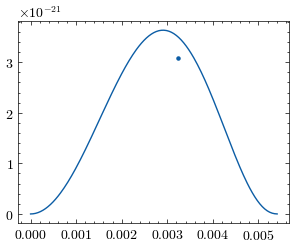

In [26]:
v_particles = np.zeros(n)

for i in tqdm(range(n)):
    v_particles[i] = sample_vel(radius_s[i], False)
    if i == n-1:     v_particles[i] = sample_vel(radius_s[i], True)
    

In [27]:
print(max(v_particles))

0.7899855863792716


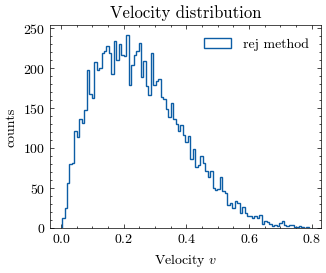

In [28]:
plt.figure()
plt.hist(v_particles, histtype = 'step', bins = int(np.sqrt(n)), label = 'rej method')
plt.xlabel("Velocity $v$")
plt.ylabel("counts")
plt.title("Velocity distribution")
plt.legend()
plt.show()

In [29]:
eps_particles = - (compute_potential(radius_s) + 0.5*v_particles**2)
print(min(eps_particles))

9.522305203930569e-06


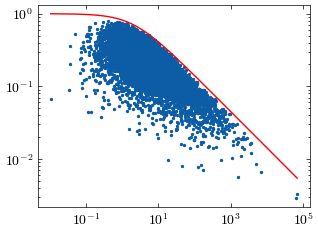

In [30]:
plt.plot(radius_s, np.sqrt(- 2 * compute_potential(radius_s)), c = 'r')
plt.scatter(radius_s, v_particles, s = 2)
plt.loglog()
plt.show()

In [31]:
P_theta_v = np.random.uniform(0, 1, n)
theta_v = np.arccos(1 - 2*P_theta_v)

P_phi_v = np.random.uniform(0, 1, n)
phi_v = 2 * np.pi * P_phi_v

vx, vy, vz = sph_to_carth (v_particles, theta_v, phi_v)

In [32]:
import datetime

def get_timestamp_filename():
    now = datetime.datetime.now()
    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
    return f"H_input_{timestamp}.txt"

In [33]:
filename = get_timestamp_filename()
print(filename)

H_input_2025-08-28_12-42-56.txt


In [34]:
BH_1_pos = str(x_1) + ' ' + str(y_1) + ' ' + str(z_1) 
BH_2_pos = str(x_2) + ' ' + str(y_2) + ' ' + str(z_2) 
BH_1_vel = str(v_x1) + ' ' + str(v_y1) + ' ' + str(v_z1) 
BH_2_vel = str(v_x2) + ' ' + str(v_y2) + ' ' + str(v_z2) 

In [35]:
inputf = open(filename, 'w')

particles_masses = str(M_BH )+ '\n' + str(M_BH) + '\n'
particles_positions = BH_1_pos + '\n' + BH_2_pos + '\n'
particles_velocities = BH_1_vel + '\n' + BH_2_vel + '\n'

for i in range(n):
    particles_masses = particles_masses + str(M/n) + '\n'
    particles_positions = particles_positions + str(x[i]) + ' ' + str(y[i]) + ' ' + str(z[i]) + '\n'
    particles_velocities = particles_velocities +  str(vx[i]) + ' ' + str(vy[i]) + ' ' + str(vz[i]) + '\n'

lines = [str(n + 2) + '\n' + str(n_dim) + '\n0\n' + particles_masses + particles_positions + particles_velocities]
inputf.writelines(lines)

inputf.close()

In [36]:
volume = 4*np.pi/3 * a**3
softening = 0.1 * (volume / n)**(1/3)
print('suggested softening parameter = ', softening)

suggested softening parameter =  0.014964407707272982


In [37]:
def compute_rho(R):
    return M / (2* np.pi) * a/R * 1/(R+a)**3

In [38]:
sphere_density = compute_rho(a)
print('\nSphere density = ', sphere_density)

dyn_time = np.sqrt((3 * np.pi)/(16 *sphere_density))
print('\nDynamical time = ', dyn_time)

collapse_time = dyn_time * np.power(2, -1/2)

print('\nCollapse time = ', collapse_time)


Sphere density =  0.0024867959858108648

Dynamical time =  15.390597961942369

Collapse time =  10.882796185405308


In [39]:
day = str(datetime.datetime.now().day)
month = str(datetime.datetime.now().month)

In [40]:
folder = '../stellar_systems_dynamics2024/final_exercise/runs/' + day + '_' + month + '/'
outname=filename.replace('input', 'output')
logname=filename.replace('input', 'log')

In [41]:
dtime = 0.05
tstop = 200
dtout = 0.1

In [42]:
command_line = ('./treecode in=' + folder + filename + ' out=' + folder + outname + 
                ' dtime=' + str(dtime) + ' eps=' + str(softening) + ' theta=0.5 tstop=' + str(tstop) + ' dtout=' + str(dtout) + ' > ' + folder + logname)

In [43]:
print(command_line)

./treecode in=../stellar_systems_dynamics2024/final_exercise/runs/28_8/H_input_2025-08-28_12-42-56.txt out=../stellar_systems_dynamics2024/final_exercise/runs/28_8/H_output_2025-08-28_12-42-56.txt dtime=0.05 eps=0.014964407707272982 theta=0.5 tstop=200 dtout=0.1 > ../stellar_systems_dynamics2024/final_exercise/runs/28_8/H_log_2025-08-28_12-42-56.txt


In [44]:
cmdname = filename.replace('input', 'cmd')

In [45]:
inputf = open(cmdname, 'w')

inputf.writelines(command_line)

inputf.close()

# Internal units to Physical units
We use the fact that $\frac{G M}{r v^2}$ is adimentional to infer the units of velocity and then those of time.
We will indicate with P our physical units (cgs) and with I the internal ones, where we fix $M_\odot$ as units of mass and kpc of lenght.

$$G_P = \frac{(\frac{r_P}{r_I})(\frac{v_P}{v_I})^2}{\frac{m_P}{m_I}} = 6.67 \times 10^{-8} \mathrm{cm}^3/\mathrm{g s}^2$$

which implies:

$$v_P = v_I \times \sqrt{G_P \, (\frac{m_P}{m_I}) \, (\frac{r_I}{r_P})} $$

In [46]:
from astropy import units as u
from astropy import constants as const

In [47]:
G = const.G.cgs

M_I = 1 * u.solMass
M_P = 10**10 * M_I.to(u.g)

R_I = 1 * u.kpc
R_P = 0.5 * R_I.to(u.cm)

v_conver = np.sqrt(G * (M_P/M_I) * (R_I/R_P))
print(v_conver)

29328884.29530274 cm kpc(1/2) / (solMass(1/2) s)


In [48]:
v_I = 1 * (u.solMass/u.kpc)**(1/2)
v_P = v_conver * v_I
print(v_I, ' = ', v_P)

1.0 solMass(1/2) / kpc(1/2)  =  29328884.29530274 cm / s


Given that $v_P$ is measured in cm/s, then $v_I$ is expressed in units of ($M_\odot$/kpc)$^{1/2}$:
$$ v_P = v_I \times 207.38652969844205 \frac{\mathrm{cm}}{\mathrm{s}}\frac{\mathrm{kpc}^{1/2}}{\mathrm{M_\odot}^{1/2}}$$

but since $v_I = \left[L/T\right]$ and lenght is measured in kpc:
$$ [T] = \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} $$

If we take $\frac{G_PM_P}{v_P^3}$ this is in units of seconds and will be equal to $\frac{G_I M_I}{v_I^3}$:

$$\frac{G_I M_I}{v_I^3} = 1  \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} = \frac{G_PM_P}{v_P^3} = ? \mathrm{s} $$

In [49]:
t_I = R_I / v_I
time_conv = (G * M_P / v_P**3) /t_I
print(time_conv)

52604755612636.17 s solMass(1/2) / kpc(3/2)


In [50]:
t_P = time_conv * t_I
print(t_I, ' = ', t_P, ' = ', t_P.to(u.Myr))

1.0 kpc(3/2) / solMass(1/2)  =  52604755612636.17 s  =  1.6669441152887472 Myr


If we instead try to compute the time from the dynamical time: